# Modelling LSTM - Model Final

Notebook ini memuat satu eksperimen LSTM untuk memprediksi nilai **ISPU PM2.5 hari berikutnya**.

Konfigurasi model yang digunakan:

| Parameter | Nilai |
|---|---:|
| Lookback | 7 hari |
| LSTM units | 128 |
| Dropout | 0.38969 |
| Dense units | 64 |
| Learning rate | 0.00139049 |
| Batch size | 64 |

Alur modelling dibuat aman untuk time series:

1. Sequence dibangun secara terpisah untuk setiap stasiun.
2. Input hanya menggunakan data historis hari `t-7` sampai `t-1`.
3. Split train, validation, dan test dilakukan berdasarkan waktu.
4. Scaler di-fit tanpa menggunakan test set.
5. Test set hanya digunakan untuk evaluasi akhir.

## 1. Setup dan Import Library

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import json
import random
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

print('TensorFlow:', tf.__version__, '| Keras:', keras.__version__)

TensorFlow: 2.21.0 | Keras: 3.14.0


## 2. Load Dataset

In [2]:
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == 'notebooks' else CURRENT_DIR
DATA_PATH = PROJECT_ROOT / 'data' / 'final for modelling' / 'dataset_final_new.csv'
DIR_OUTPUT = PROJECT_ROOT / 'notebooks' / 'outputs'
DIR_OUTPUT.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset tidak ditemukan: {DATA_PATH}')

df_raw = pd.read_csv(DATA_PATH, parse_dates=['tanggal'])
TARGET = 'ISPU PM2.5'
KOLOM_CUACA = ['temp', 'humidity', 'visibility', 'windgust', 'solarenergy', 'precip']
KOLOM_WAJIB = ['tanggal', TARGET, 'station', 'bulan', 'hari_minggu'] + KOLOM_CUACA

kolom_hilang = [c for c in KOLOM_WAJIB if c not in df_raw.columns]
if kolom_hilang:
    raise KeyError(f'Kolom wajib tidak ditemukan: {kolom_hilang}')

print('Dataset :', DATA_PATH)
print('Shape   :', df_raw.shape)
print('Tanggal :', df_raw['tanggal'].min().date(), '->', df_raw['tanggal'].max().date())
print('Stasiun :', df_raw['station'].nunique())
display(df_raw.head())

Dataset : C:\Users\User\Air Pollution - Daming Project\data\final for modelling\dataset_final_new.csv
Shape   : (7672, 12)
Tanggal : 2022-01-01 -> 2024-12-31
Stasiun : 7


,tanggal,ISPU PM2.5,kategori_pm25,bulan,hari_minggu,temp,humidity,visibility,windgust,solarenergy,precip,station
0,2022-01-01,74.0,Sedang,1,5,28.6,77.2,6.7,37.1,20.6,0.496,bundaran hi
1,2022-01-01,73.0,Sedang,1,5,28.3,77.8,6.8,37.1,20.6,0.502,jagakarsa
2,2022-01-01,69.0,Sedang,1,5,28.3,79.3,7.5,37.1,20.6,0.645,kebun jeruk
3,2022-01-01,76.0,Sedang,1,5,28.6,76.9,6.7,34.9,21.0,0.262,kelapa gading
4,2022-01-01,87.0,Sedang,1,5,28.5,76.8,6.2,34.9,21.0,0.451,lubang buaya


## 3. Feature Engineering

Fitur setiap timestep terdiri dari:

- Nilai historis `ISPU PM2.5`
- Enam fitur cuaca
- Representasi siklikal bulan dan hari
- Musim Jakarta
- Identitas stasiun dalam bentuk one-hot encoding

In [3]:
data = df_raw.copy()
data['station'] = data['station'].astype(str).str.strip().str.lower()
data = data.dropna(subset=[TARGET]).copy()
data = data.sort_values(['station', 'tanggal']).reset_index(drop=True)

data['bulan_sin'] = np.sin(2 * np.pi * data['bulan'] / 12)
data['bulan_cos'] = np.cos(2 * np.pi * data['bulan'] / 12)
data['hari_minggu_sin'] = np.sin(2 * np.pi * data['hari_minggu'] / 7)
data['hari_minggu_cos'] = np.cos(2 * np.pi * data['hari_minggu'] / 7)

def label_musim(bulan):
    if bulan in (11, 12, 1, 2, 3):
        return 'Hujan'
    if bulan == 4:
        return 'Transisi'
    return 'Kemarau'

data['musim'] = data['bulan'].map(label_musim)

station_dummies = pd.get_dummies(data['station'], prefix='station', dtype=float)
musim_dummies = pd.get_dummies(data['musim'], prefix='musim', dtype=float)

for col in ['musim_Hujan', 'musim_Kemarau', 'musim_Transisi']:
    if col not in musim_dummies.columns:
        musim_dummies[col] = 0.0

data = pd.concat([data, station_dummies, musim_dummies], axis=1)
station_cols = sorted(station_dummies.columns.tolist())
musim_cols = ['musim_Hujan', 'musim_Kemarau', 'musim_Transisi']

FITUR_LSTM = (
    [TARGET]
    + KOLOM_CUACA
    + ['bulan_sin', 'bulan_cos', 'hari_minggu_sin', 'hari_minggu_cos']
    + musim_cols
    + station_cols
)

jumlah_missing = int(data[FITUR_LSTM].isna().sum().sum())
if jumlah_missing:
    raise ValueError(f'Masih ada {jumlah_missing} missing value pada fitur LSTM.')

print('Jumlah baris             :', f'{len(data):,}')
print('Jumlah fitur per timestep:', len(FITUR_LSTM))
print('Missing value fitur      :', jumlah_missing)
print('Kolom stasiun one-hot    :', station_cols)

Jumlah baris             : 7,672
Jumlah fitur per timestep: 21
Missing value fitur      : 0
Kolom stasiun one-hot    : ['station_bundaran hi', 'station_jagakarsa', 'station_kebun jeruk', 'station_kelapa gading', 'station_lubang buaya', 'station_us embassy 1', 'station_us embassy 2']


## 4. Build Sequence per Stasiun

Untuk setiap target PM2.5 hari ke-`t`, input model hanya berisi riwayat hari `t-7` sampai `t-1`.

In [4]:
LOOKBACK = 7

def bangun_sequences(df, fitur, target, lookback):
    X_list, y_list, tanggal_list, station_list = [], [], [], []

    for station, sub in df.groupby('station'):
        sub = sub.sort_values('tanggal').reset_index(drop=True)
        fitur_array = sub[fitur].to_numpy(dtype=np.float32)
        target_array = sub[target].to_numpy(dtype=np.float32)
        tanggal_array = sub['tanggal'].to_numpy()

        for i in range(lookback, len(sub)):
            X_list.append(fitur_array[i - lookback:i])
            y_list.append(target_array[i])
            tanggal_list.append(tanggal_array[i])
            station_list.append(station)

    return (
        np.stack(X_list),
        np.asarray(y_list, dtype=np.float32),
        pd.to_datetime(np.asarray(tanggal_list)),
        np.asarray(station_list),
    )

X_seq, y_seq, tanggal_seq, station_seq = bangun_sequences(data, FITUR_LSTM, TARGET, LOOKBACK)

print('Lookback              :', LOOKBACK, 'hari')
print('Jumlah sequence       :', f'{len(X_seq):,}')
print('Shape input (N, L, F) :', X_seq.shape)
print('Shape target          :', y_seq.shape)
print('Tanggal target        :', tanggal_seq.min().date(), '->', tanggal_seq.max().date())
display(pd.Series(station_seq).value_counts().sort_index().to_frame('jumlah_sequence'))

Lookback              : 7 hari
Jumlah sequence       : 7,623
Shape input (N, L, F) : (7623, 7, 21)
Shape target          : (7623,)
Tanggal target        : 2022-01-08 -> 2024-12-31


,jumlah_sequence
bundaran hi,1089
jagakarsa,1089
kebun jeruk,1089
kelapa gading,1089
lubang buaya,1089
us embassy 1,1089
us embassy 2,1089


In [5]:
# Verifikasi singkat bahwa PM2.5 hari target tidak masuk ke input sequence.
idx_target = FITUR_LSTM.index(TARGET)
rng = np.random.RandomState(RANDOM_STATE)

for idx in rng.choice(len(X_seq), size=5, replace=False):
    station = station_seq[idx]
    tanggal_target = pd.Timestamp(tanggal_seq[idx])
    sub = data[data['station'] == station].sort_values('tanggal').reset_index(drop=True)
    posisi_target = sub.index[sub['tanggal'] == tanggal_target][0]

    pm25_input_terakhir = float(X_seq[idx, -1, idx_target])
    pm25_hari_sebelumnya = float(sub.loc[posisi_target - 1, TARGET])
    pm25_target = float(sub.loc[posisi_target, TARGET])

    assert np.isclose(pm25_input_terakhir, pm25_hari_sebelumnya)
    assert np.isclose(float(y_seq[idx]), pm25_target)

print('Verifikasi anti-leakage sequence lolos.')

Verifikasi anti-leakage sequence lolos.


## 5. Time-based Split dan Scaling

Data dibagi `70% / 15% / 15%` berdasarkan tanggal target sequence. Scaler untuk tahap training awal hanya di-fit pada train set.

In [6]:
tanggal_unik = np.asarray(sorted(np.unique(tanggal_seq)))
batas_train = pd.Timestamp(tanggal_unik[int(len(tanggal_unik) * 0.70)])
batas_validasi = pd.Timestamp(tanggal_unik[int(len(tanggal_unik) * 0.85)])

mask_train = np.asarray(tanggal_seq < batas_train)
mask_validasi = np.asarray((tanggal_seq >= batas_train) & (tanggal_seq < batas_validasi))
mask_test = np.asarray(tanggal_seq >= batas_validasi)

X_train, y_train = X_seq[mask_train], y_seq[mask_train]
X_validasi, y_validasi = X_seq[mask_validasi], y_seq[mask_validasi]
X_test, y_test = X_seq[mask_test], y_seq[mask_test]

info_split = pd.DataFrame([
    {
        'subset': 'Train',
        'jumlah_sequence': int(mask_train.sum()),
        'mulai': tanggal_seq[mask_train].min().date(),
        'akhir': tanggal_seq[mask_train].max().date(),
    },
    {
        'subset': 'Validation',
        'jumlah_sequence': int(mask_validasi.sum()),
        'mulai': tanggal_seq[mask_validasi].min().date(),
        'akhir': tanggal_seq[mask_validasi].max().date(),
    },
    {
        'subset': 'Test',
        'jumlah_sequence': int(mask_test.sum()),
        'mulai': tanggal_seq[mask_test].min().date(),
        'akhir': tanggal_seq[mask_test].max().date(),
    },
])
display(info_split)

n_fitur = X_train.shape[2]
scaler_X_train = StandardScaler().fit(X_train.reshape(-1, n_fitur))
scaler_y_train = StandardScaler().fit(y_train.reshape(-1, 1))

def transform_X(scaler, values):
    return scaler.transform(values.reshape(-1, n_fitur)).reshape(values.shape).astype(np.float32)

def transform_y(scaler, values):
    return scaler.transform(values.reshape(-1, 1)).ravel().astype(np.float32)

X_train_s = transform_X(scaler_X_train, X_train)
X_validasi_s = transform_X(scaler_X_train, X_validasi)
y_train_s = transform_y(scaler_y_train, y_train)
y_validasi_s = transform_y(scaler_y_train, y_validasi)

print(f'Train X scaled      : mean={X_train_s.mean():+.4f} std={X_train_s.std():.4f}')
print(f'Validation X scaled : mean={X_validasi_s.mean():+.4f} std={X_validasi_s.std():.4f}')

,subset,jumlah_sequence,mulai,akhir
0,Train,5334,2022-01-08,2024-02-08
1,Validation,1141,2024-02-09,2024-07-20
2,Test,1148,2024-07-21,2024-12-31


Train X scaled      : mean=-0.0000 std=1.0000
Validation X scaled : mean=+0.0126 std=1.0317


## 6. Definisi Satu Model LSTM

In [7]:
PARAMS_MODEL = {
    'units': 128,
    'dropout': 0.38969,
    'learning_rate': 0.00139049,
}

def bangun_model_lstm(params, lookback, jumlah_fitur):
    units = int(params['units'])
    model = keras.Sequential([
        layers.Input(shape=(lookback, jumlah_fitur)),
        layers.LSTM(units),
        layers.Dropout(float(params['dropout'])),
        layers.Dense(max(16, units // 2), activation='relu'),
        layers.Dense(1),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=float(params['learning_rate'])),
        loss='mse',
        metrics=['mae'],
    )
    return model

tf.keras.utils.set_random_seed(RANDOM_STATE)
model_validasi = bangun_model_lstm(PARAMS_MODEL, LOOKBACK, n_fitur)
model_validasi.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        76,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,121 (332.50 KB)

 Trainable params: 85,121 (332.50 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Training dan Penentuan Jumlah Epoch

Validation set digunakan untuk menentukan jumlah epoch melalui `EarlyStopping`. Test set belum digunakan pada tahap ini.

In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        patience=3,
        factor=0.5,
        min_lr=1e-5,
        verbose=1,
    ),
]

mulai = time.time()
history = model_validasi.fit(
    X_train_s,
    y_train_s,
    validation_data=(X_validasi_s, y_validasi_s),
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=0,
)
waktu_training_validasi = time.time() - mulai
epoch_terbaik = int(np.argmin(history.history['val_loss'])) + 1

print(f'Waktu training awal : {waktu_training_validasi:.1f} detik')
print(f'Jumlah epoch jalan  : {len(history.history["loss"])}')
print(f'Epoch terbaik       : {epoch_terbaik}')


Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0006952449912205338.



Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0003476224956102669.


Epoch 16: early stopping


Restoring model weights from the end of the best epoch: 10.


Waktu training awal : 10.9 detik
Jumlah epoch jalan  : 16
Epoch terbaik       : 10


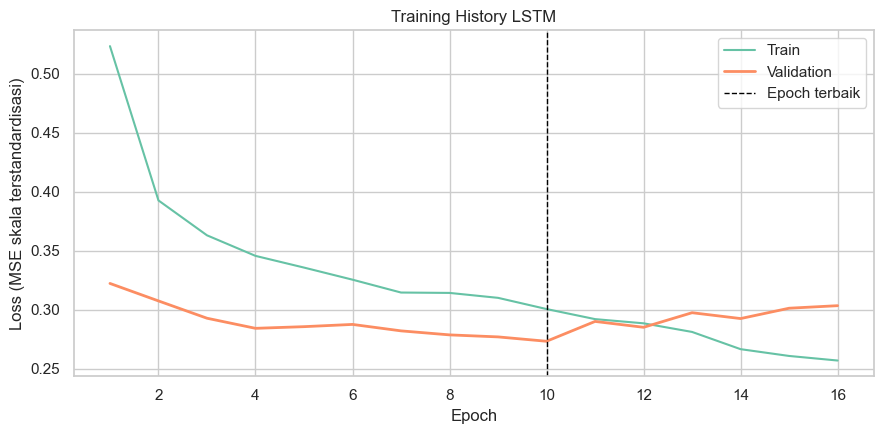

In [9]:
plt.figure(figsize=(9, 4.5))
rentang_epoch = np.arange(1, len(history.history['loss']) + 1)
plt.plot(rentang_epoch, history.history['loss'], label='Train')
plt.plot(rentang_epoch, history.history['val_loss'], label='Validation', linewidth=2)
plt.axvline(epoch_terbaik, color='black', linestyle='--', linewidth=1, label='Epoch terbaik')
plt.title('Training History LSTM')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE skala terstandardisasi)')
plt.legend()
plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'training_history_lstm_new.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Final Training dan Evaluasi Test

Setelah jumlah epoch ditentukan, model final dilatih ulang pada gabungan train dan validation. Test set tetap tidak ikut dilatih.

In [10]:
X_train_validasi = np.concatenate([X_train, X_validasi])
y_train_validasi = np.concatenate([y_train, y_validasi])

scaler_X_final = StandardScaler().fit(X_train_validasi.reshape(-1, n_fitur))
scaler_y_final = StandardScaler().fit(y_train_validasi.reshape(-1, 1))

X_train_validasi_s = transform_X(scaler_X_final, X_train_validasi)
X_test_s = transform_X(scaler_X_final, X_test)
y_train_validasi_s = transform_y(scaler_y_final, y_train_validasi)

keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_STATE)
model_final = bangun_model_lstm(PARAMS_MODEL, LOOKBACK, n_fitur)

mulai = time.time()
model_final.fit(
    X_train_validasi_s,
    y_train_validasi_s,
    epochs=max(1, epoch_terbaik),
    batch_size=64,
    verbose=0,
)
waktu_training_final = time.time() - mulai

prediksi_test_s = model_final.predict(X_test_s, verbose=0)
prediksi_test = scaler_y_final.inverse_transform(prediksi_test_s.reshape(-1, 1)).ravel()

print(f'Waktu training final: {waktu_training_final:.1f} detik')

Waktu training final: 7.5 detik


In [11]:
URUTAN_KATEGORI_ISPU = ['Baik', 'Sedang', 'Tidak Sehat', 'Sangat Tidak Sehat', 'Berbahaya']

def mape_aman(y_aktual, y_prediksi, epsilon=1.0):
    y_aktual = np.asarray(y_aktual, dtype=float)
    y_prediksi = np.asarray(y_prediksi, dtype=float)
    mask = np.abs(y_aktual) > epsilon
    return float(np.mean(np.abs((y_aktual[mask] - y_prediksi[mask]) / y_aktual[mask])) * 100)

def hitung_metrik_regresi(y_aktual, y_prediksi):
    return {
        'MAE': float(mean_absolute_error(y_aktual, y_prediksi)),
        'RMSE': float(mean_squared_error(y_aktual, y_prediksi) ** 0.5),
        'R2': float(r2_score(y_aktual, y_prediksi)),
        'MAPE': mape_aman(y_aktual, y_prediksi),
    }

def kategori_ispu(nilai):
    if nilai <= 50:
        return 'Baik'
    if nilai <= 100:
        return 'Sedang'
    if nilai < 200:
        return 'Tidak Sehat'
    if nilai < 300:
        return 'Sangat Tidak Sehat'
    return 'Berbahaya'

metrik_test = hitung_metrik_regresi(y_test, prediksi_test)
tabel_metrik_test = pd.DataFrame([metrik_test], index=['LSTM Final']).round(4)
display(tabel_metrik_test)

detail_prediksi = pd.DataFrame({
    'tanggal': tanggal_seq[mask_test],
    'station': station_seq[mask_test],
    TARGET: y_test,
    'prediksi_pm25': prediksi_test,
})
detail_prediksi['residual'] = detail_prediksi[TARGET] - detail_prediksi['prediksi_pm25']
detail_prediksi['abs_error'] = detail_prediksi['residual'].abs()
detail_prediksi['kategori_aktual'] = detail_prediksi[TARGET].map(kategori_ispu)
detail_prediksi['kategori_prediksi'] = detail_prediksi['prediksi_pm25'].map(kategori_ispu)

label_tersedia = [
    label for label in URUTAN_KATEGORI_ISPU
    if label in set(detail_prediksi['kategori_aktual']) | set(detail_prediksi['kategori_prediksi'])
]

report_kategori = classification_report(
    detail_prediksi['kategori_aktual'],
    detail_prediksi['kategori_prediksi'],
    labels=URUTAN_KATEGORI_ISPU,
    output_dict=True,
    zero_division=0,
)

metrik_kategori = {
    'accuracy': float(accuracy_score(detail_prediksi['kategori_aktual'], detail_prediksi['kategori_prediksi'])),
    'macro_f1': float(f1_score(
        detail_prediksi['kategori_aktual'],
        detail_prediksi['kategori_prediksi'],
        labels=label_tersedia,
        average='macro',
        zero_division=0,
    )),
    'weighted_f1': float(f1_score(
        detail_prediksi['kategori_aktual'],
        detail_prediksi['kategori_prediksi'],
        labels=label_tersedia,
        average='weighted',
        zero_division=0,
    )),
    'recall_tidak_sehat': float(report_kategori['Tidak Sehat']['recall']),
}

display(pd.DataFrame([metrik_kategori], index=['LSTM Final']).round(4))

,MAE,RMSE,R2,MAPE
LSTM Final,9.9733,14.2795,0.5498,19.1599


,accuracy,macro_f1,weighted_f1,recall_tidak_sehat
LSTM Final,0.8502,0.6182,0.8331,0.2105


### Evaluasi Khusus PM2.5 Tinggi

In [12]:
mask_pm25_tinggi = np.asarray(y_test) > 100
y_test_tinggi = np.asarray(y_test)[mask_pm25_tinggi]
prediksi_test_tinggi = np.asarray(prediksi_test)[mask_pm25_tinggi]

evaluasi_pm25_tinggi = {
    'jumlah_aktual_PM25_gt_100': int(mask_pm25_tinggi.sum()),
    'jumlah_prediksi_PM25_gt_100': int((np.asarray(prediksi_test) > 100).sum()),
    'jumlah_terdeteksi_PM25_gt_100': int((prediksi_test_tinggi > 100).sum()),
    'MAE_PM25_gt_100': float(mean_absolute_error(y_test_tinggi, prediksi_test_tinggi)),
    'RMSE_PM25_gt_100': float(mean_squared_error(y_test_tinggi, prediksi_test_tinggi) ** 0.5),
    'rata_aktual_PM25_gt_100': float(y_test_tinggi.mean()),
    'rata_prediksi_PM25_gt_100': float(prediksi_test_tinggi.mean()),
}

display(pd.DataFrame([evaluasi_pm25_tinggi], index=['LSTM Final']).round(4))

,jumlah_aktual_PM25_gt_100,jumlah_prediksi_PM25_gt_100,jumlah_terdeteksi_PM25_gt_100,MAE_PM25_gt_100,RMSE_PM25_gt_100,rata_aktual_PM25_gt_100,rata_prediksi_PM25_gt_100
LSTM Final,76,30,16,17.689,21.1328,108.6376,91.3075


## 9. Visualisasi Evaluasi

Visualisasi difokuskan pada aktual vs prediksi dan confusion matrix kategori ISPU. Distribusi residual tidak digunakan pada notebook ini.

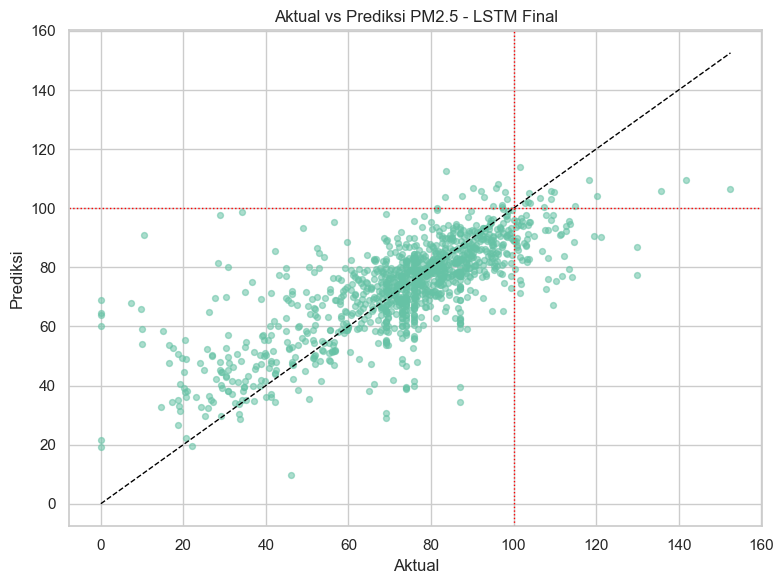

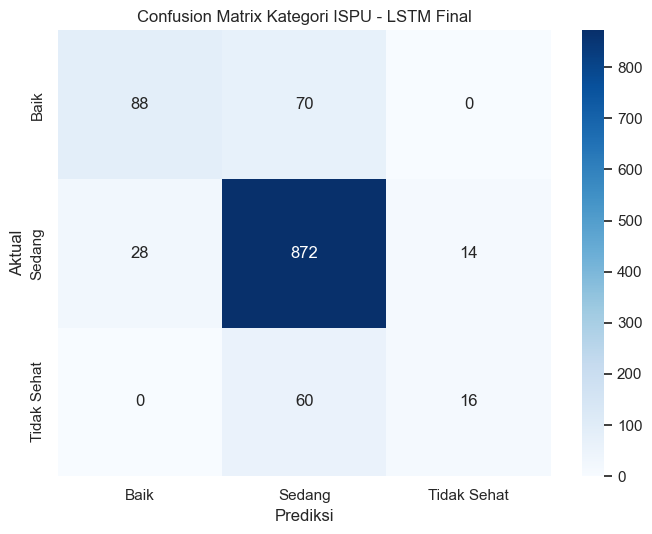

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, prediksi_test, alpha=0.55, s=18)
batas_min = float(min(np.min(y_test), np.min(prediksi_test)))
batas_max = float(max(np.max(y_test), np.max(prediksi_test)))
plt.plot([batas_min, batas_max], [batas_min, batas_max], 'k--', linewidth=1)
plt.axhline(100, color='red', linestyle=':', linewidth=1)
plt.axvline(100, color='red', linestyle=':', linewidth=1)
plt.title('Aktual vs Prediksi PM2.5 - LSTM Final')
plt.xlabel('Aktual')
plt.ylabel('Prediksi')
plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'actual_vs_predicted_lstm_new.png', dpi=150, bbox_inches='tight')
plt.show()

cm = confusion_matrix(
    detail_prediksi['kategori_aktual'],
    detail_prediksi['kategori_prediksi'],
    labels=label_tersedia,
)
plt.figure(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_tersedia, yticklabels=label_tersedia)
plt.title('Confusion Matrix Kategori ISPU - LSTM Final')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'confusion_matrix_lstm_new.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Simpan Model dan Output

In [14]:
model_final.save(DIR_OUTPUT / 'model_lstm_new.keras')
joblib.dump(
    {
        'scaler_X': scaler_X_final,
        'scaler_y': scaler_y_final,
        'fitur': FITUR_LSTM,
        'lookback': LOOKBACK,
    },
    DIR_OUTPUT / 'scaler_lstm_new.pkl',
)

detail_prediksi.to_csv(DIR_OUTPUT / 'prediksi_vs_aktual_lstm_new.csv', index=False)
pd.DataFrame(report_kategori).transpose().round(4).to_csv(
    DIR_OUTPUT / 'classification_report_lstm_new.csv'
)
pd.DataFrame([evaluasi_pm25_tinggi]).round(4).to_csv(
    DIR_OUTPUT / 'evaluasi_pm25_tinggi_lstm_new.csv',
    index=False,
)

metadata = {
    'model_name': 'LSTM Final',
    'algoritma': 'LSTM (Keras)',
    'params': PARAMS_MODEL,
    'lookback': LOOKBACK,
    'epoch_terbaik': epoch_terbaik,
    'n_features': len(FITUR_LSTM),
    'features_per_timestep': FITUR_LSTM,
    'target': TARGET,
    'dataset': DATA_PATH.name,
    'skema_split': 'time-based 70/15/15 pada tanggal target sequence',
    'final_model_dilatih_pada': 'train + validation; test tidak dipakai untuk training',
    'rentang_train': [
        str(pd.Timestamp(tanggal_seq[mask_train].min()).date()),
        str(pd.Timestamp(tanggal_seq[mask_train].max()).date()),
    ],
    'rentang_validation': [
        str(pd.Timestamp(tanggal_seq[mask_validasi].min()).date()),
        str(pd.Timestamp(tanggal_seq[mask_validasi].max()).date()),
    ],
    'rentang_test': [
        str(pd.Timestamp(tanggal_seq[mask_test].min()).date()),
        str(pd.Timestamp(tanggal_seq[mask_test].max()).date()),
    ],
    'metrik_test': metrik_test,
    'metrik_kategori_test': metrik_kategori,
    'evaluasi_pm25_tinggi_test': evaluasi_pm25_tinggi,
}

(DIR_OUTPUT / 'metadata_lstm_new.json').write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False),
    encoding='utf-8',
)

print('Output tersimpan di:', DIR_OUTPUT)
print('- model_lstm_new.keras')
print('- scaler_lstm_new.pkl')
print('- metadata_lstm_new.json')
print('- prediksi_vs_aktual_lstm_new.csv')
print('- classification_report_lstm_new.csv')
print('- evaluasi_pm25_tinggi_lstm_new.csv')
print('- training_history_lstm_new.png')
print('- actual_vs_predicted_lstm_new.png')
print('- confusion_matrix_lstm_new.png')

Output tersimpan di: C:\Users\User\Air Pollution - Daming Project\notebooks\outputs
- model_lstm_new.keras
- scaler_lstm_new.pkl
- metadata_lstm_new.json
- prediksi_vs_aktual_lstm_new.csv
- classification_report_lstm_new.csv
- evaluasi_pm25_tinggi_lstm_new.csv
- training_history_lstm_new.png
- actual_vs_predicted_lstm_new.png
- confusion_matrix_lstm_new.png


## 11. Kesimpulan

Notebook ini menggunakan satu model LSTM final dengan `lookback=7`. Input sequence dibangun per stasiun dan hanya memakai data historis. Pemisahan data serta scaling dilakukan secara time-based untuk mencegah kebocoran informasi dari masa depan.

Evaluasi PM2.5 tinggi tetap dicantumkan karena kejadian dengan nilai `ISPU PM2.5 > 100` penting untuk melihat kemampuan model dalam mendeteksi kondisi udara tidak sehat.